In [2]:
import pandas as pd
import numpy as np
import pmdarima as pm
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load Preprocessed Data (v2)

In [7]:
# Load corrected monthly data
data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
df = pd.read_csv(data_path, parse_dates=['date'])
df = df.set_index('date').asfreq('MS')  # Monthly start frequency

# Extract temperature series
temp_series = df['temperature_2m_mean'].copy()
temp_series = temp_series.fillna(method='ffill')  # Forward fill any NaNs

print(f"Data loaded: {len(temp_series)} months from {temp_series.index.min()} to {temp_series.index.max()}")
print(f"Temperature range: {temp_series.min():.2f}°C to {temp_series.max():.2f}°C")

Data loaded: 260 months from 2002-01-01 00:00:00 to 2023-08-01 00:00:00
Temperature range: 7.07°C to 29.15°C


## 2. Fit SARIMA on Full Dataset

Using `pmdarima.auto_arima` with seasonal period m=12 (monthly data).

In [8]:
# Auto ARIMA with seasonal components
print('Fitting SARIMA model (this may take a few minutes)...')

model = pm.auto_arima(
    temp_series,
    seasonal=True,
    m=12,  # Monthly seasonality
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,  # Auto-detect differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_jobs=-1
)

print('\nModel fitted!')
print(model.summary())

Fitting SARIMA model (this may take a few minutes)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1648.960, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1228.242, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2263.303, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1388.635, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=865.472, Time=0.48 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=977.038, Time=0.20 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=861.243, Time=0.93 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1172.586, Time=0.28 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=855.386, Time=0.83 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=1105.949, Tim

## 3. Forecast to December 2040

In [9]:
# Calculate forecast horizon
last_date = temp_series.index.max()
target_date = pd.Timestamp('2040-12-01')
n_periods = (target_date.year - last_date.year) * 12 + (target_date.month - last_date.month)

if n_periods <= 0:
    raise ValueError(f"Target date {target_date} is not after last observation {last_date}")

print(f"Forecasting {n_periods} months from {last_date} to {target_date}")

# Generate forecast with 95% confidence intervals
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True, alpha=0.05)

# Create forecast dataframe
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_periods, freq='MS')
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'temperature_forecast': forecast,
    'lower_95': conf_int[:, 0],
    'upper_95': conf_int[:, 1]
})

print("\nForecast preview:")
print(forecast_df.head())
print("...")
print(forecast_df.tail())

Forecasting 208 months from 2023-08-01 00:00:00 to 2040-12-01 00:00:00

Forecast preview:
                 date  temperature_forecast   lower_95   upper_95
2023-09-01 2023-09-01             23.975260  21.828511  26.122009
2023-10-01 2023-10-01             20.151938  17.827059  22.476817
2023-11-01 2023-11-01             15.338644  12.984344  17.692943
2023-12-01 2023-12-01             12.589224  10.229888  14.948560
2024-01-01 2024-01-01             10.767918   8.407778  13.128058
...
                 date  temperature_forecast   lower_95   upper_95
2040-08-01 2040-08-01             26.610361  23.847540  29.373183
2040-09-01 2040-09-01             23.844843  21.063108  26.626579
2040-10-01 2040-10-01             20.108437  17.323446  22.893429
2040-11-01 2040-11-01             15.392681  12.607129  18.178233
2040-12-01 2040-12-01             12.698065   9.912425  15.483705


## 4. Visualize Forecast

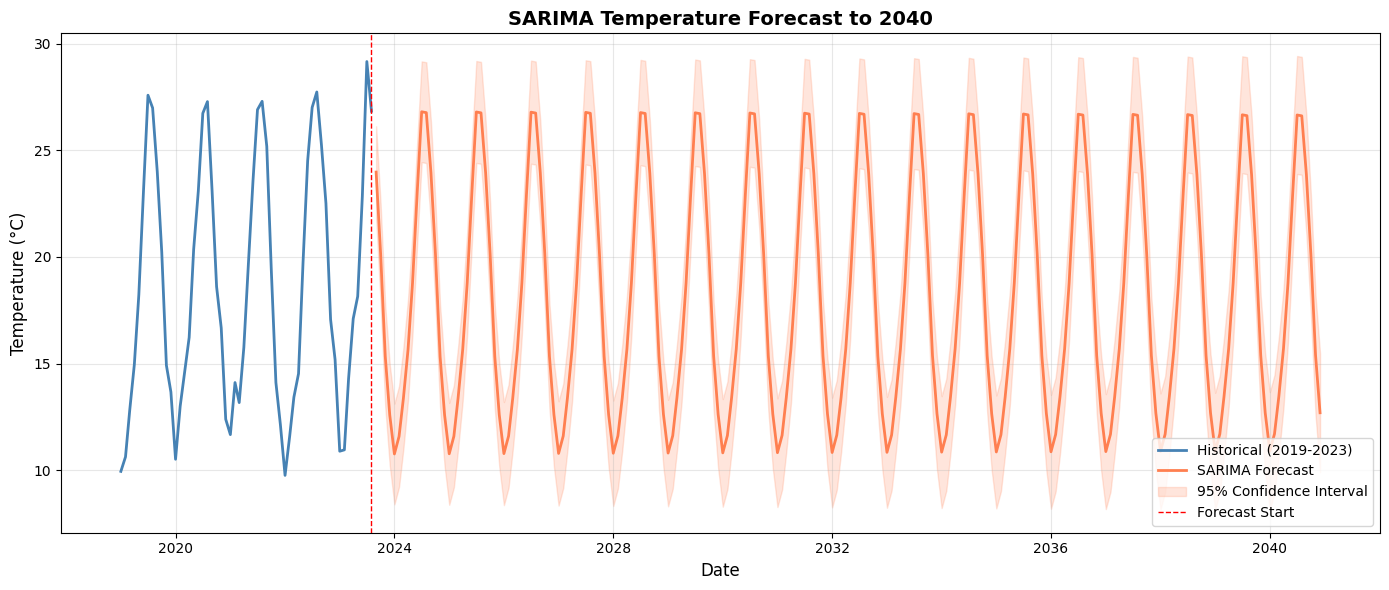

Plot saved to Results/sarima_forecast_plot.png


In [10]:
# Plot historical + forecast
plt.figure(figsize=(14, 6))

# Historical data (last 5 years for clarity)
recent_history = temp_series.loc['2019':]
plt.plot(recent_history.index, recent_history.values, label='Historical (2019-2023)', color='steelblue', linewidth=2)

# Forecast
plt.plot(forecast_df['date'], forecast_df['temperature_forecast'], label='SARIMA Forecast', color='coral', linewidth=2)
plt.fill_between(forecast_df['date'], forecast_df['lower_95'], forecast_df['upper_95'], 
                 alpha=0.2, color='coral', label='95% Confidence Interval')

plt.axvline(last_date, color='red', linestyle='--', linewidth=1, label='Forecast Start')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('SARIMA Temperature Forecast to 2040', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Results/sarima_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Plot saved to Results/sarima_forecast_plot.png')

## 5. Save Model & Forecast

In [11]:
# Save forecast CSV
forecast_path = Path('../Predictions/sarima_forecast_2040_final.csv')
forecast_df.to_csv(forecast_path, index=False)
print(f"Forecast saved to: {forecast_path}")

# Save model
model_path = Path('../Models/sarima_model_final.pkl')
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

print('\nSARIMA pipeline complete!')

Forecast saved to: ..\Predictions\sarima_forecast_2040_final.csv
Model saved to: ..\Models\sarima_model_final.pkl

SARIMA pipeline complete!


## Summary Statistics

In [12]:
print("Forecast Summary:")
print(f"Mean forecast temperature: {forecast_df['temperature_forecast'].mean():.2f}°C")
print(f"Min forecast: {forecast_df['temperature_forecast'].min():.2f}°C")
print(f"Max forecast: {forecast_df['temperature_forecast'].max():.2f}°C")
print(f"Std deviation: {forecast_df['temperature_forecast'].std():.2f}°C")
print(f"\nForecast uncertainty (avg CI width): {(forecast_df['upper_95'] - forecast_df['lower_95']).mean():.2f}°C")

Forecast Summary:
Mean forecast temperature: 18.23°C
Min forecast: 10.77°C
Max forecast: 26.80°C
Std deviation: 5.54°C

Forecast uncertainty (avg CI width): 5.14°C
